## Step 1: Data loading + audit + export artifacts

In [1]:
! pip install tqdm

In [2]:
import os
import cv2
import pickle
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
data_dir = "datasets_pkl"

In [3]:

#  save dataset pickle file helper
def save_pkl(obj, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(obj, f)

## Dummy

In [6]:

with open(os.path.join(data_dir, 'QuishingDataset_Trad.et.al', 'qr_codes_29.pickle'), 'rb') as f:
    qr_codes = pickle.load(f)

# Load labels
with open(os.path.join(data_dir, 'QuishingDataset_Trad.et.al', 'qr_codes_29_labels.pickle'), 'rb') as f:
    labels = pickle.load(f)

print(type(qr_codes), qr_codes.shape)
print(type(labels), labels.shape)

<class 'numpy.ndarray'> (9987, 69, 69)
<class 'numpy.ndarray'> (9987,)


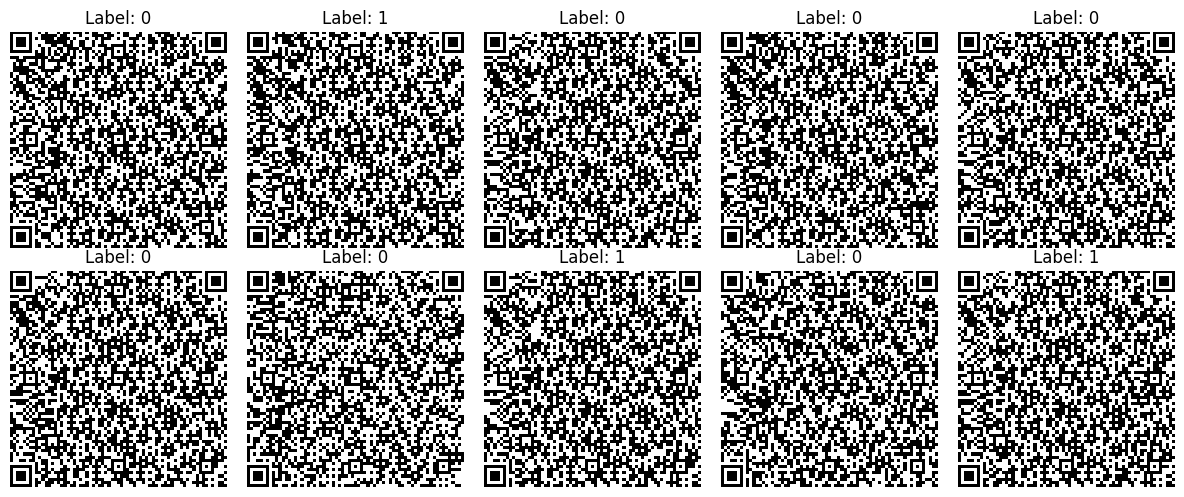

In [7]:
# Select 10 random samples
indices = np.random.choice(len(qr_codes), 10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(qr_codes[indices[i]], cmap="gray")
    ax.set_title(f"Label: {labels[indices[i]]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
def pad_to_shape(img, target_shape):
    h, w = img.shape
    th, tw = target_shape

    padded = np.zeros((th, tw), dtype=img.dtype)
    padded[:min(h, th), :min(w, tw)] = img[:th, :tw]
    return padded

In [9]:
# load kaggle (no resize)
def load_kaggle(base_dir):
    images, labels, shapes = [], [], set()

    for label_name, label in [("benign", 0), ("malicious", 1)]:
        folder = os.path.join(base_dir, label_name, label_name)

        for file in tqdm(os.listdir(folder), desc=f"Loading {label_name}"):
            if file.endswith(".png"):
                path = os.path.join(folder, file)
                # print(f"Processing file: {path}")

                img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
                if img is None:
                    print(f"Warning: Could not read image {path}. Skipping.")
                    continue
                # img = img.astype(np.float32) / 255.0  # normalize
                # fix memory error by converting to uint8
                # print(f"Image shape: {img.shape}, dtype: {img.dtype}")
                shapes.add(img.shape)
                # img = pad_to_shape(img, (224, 224))
                images.append(img)
                labels.append(label)

    print("[Dataset] image sizes:", shapes)
    return np.array(images, dtype=object), np.array(labels)


In [ ]:
kaggle_dir = "datasets/QRcodes_kaggle"
X, y = load_kaggle(kaggle_dir)
print("Kaggle dataset loaded:", X.shape, y.shape)


In [ ]:
save_pkl(X, os.path.join(data_dir, "QuishingDataset_kaggle", "qrcodes_kaggle.pkl"))
save_pkl(y, os.path.join(data_dir, "QuishingDataset_kaggle", "qrcodes_labels_kaggle.pkl"))

## CIC Trap4phish

In [4]:
! pip install qreader

In [5]:
from qreader import QReader

def decode_qr_images(images):
    qr_decoder = QReader()
    decoded_texts = []

    for img in tqdm(images, desc="Decoding QR codes"):
        text = qr_decoder.detect_and_decode(img)
        decoded_texts.append(text[0] if text and text[0] else "")

    return decoded_texts

In [6]:
base_dir= "datasets/QRcodes_CIC_trap4phish"

def load_cic(base_dir, resize_to=None):
    """Load CIC dataset with optional resizing to reduce memory usage"""
    images, labels, shapes, filenames = [], [], set(), []

    classes = [
        ("QR_All_benign/qrs", 0),
        ("QR_All_malicious/qrs", 1)
    ]

    for sub, lab in classes:
        folder = os.path.join(base_dir, sub)
        for f in tqdm(os.listdir(folder), desc=sub):
            if not f.endswith(".png"):
                continue
            path = os.path.join(folder, f)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            shapes.add(img.shape)
            
            # Resize if specified (helps reduce memory usage)
            if resize_to:
                img = cv2.resize(img, (resize_to, resize_to))
            
            # Keep as uint8 to save memory (don't normalize to float64)
            images.append(img)
            labels.append(lab)
            filenames.append(f)

    print("CIC image sizes:", shapes)
    return np.array(images, dtype=object), np.array(labels), np.array(filenames)


In [7]:
import pandas as pd
df_benign = pd.read_csv("datasets/QRcodes_CIC_trap4phish/QR_All_benign/all_generated_urls_20251015_161937.csv")
df_malicious = pd.read_csv("datasets/QRcodes_CIC_trap4phish/QR_All_Malicious/all_generated_urls_20251015_184324.csv")
df_benign.head()
df_malicious.head()

,index,url,qr_path
0,1,https://www.amazon.com/ref=pe_175190_21431760_...,Output\QR_All_Malicious\qrs\benign_000001.png
1,2,http://g-ecx.images-amazon.com/images/G/01/x-l...,Output\QR_All_Malicious\qrs\benign_000002.png
2,3,http://irc-sspo.uz/a,Output\QR_All_Malicious\qrs\benign_000003.png
3,4,http://www.amazon.com/gp/css/returns/homepage....,Output\QR_All_Malicious\qrs\benign_000004.png
4,5,http://www.amazon.com/customer-service?ref=pe_...,Output\QR_All_Malicious\qrs\benign_000005.png


In [10]:
# Load CIC dataset with resizing to NxN to avoid memory issues
X, y, filenames = load_cic(base_dir, resize_to=29)
print(f"CIC dataset loaded: Images shape {X.shape}, Labels shape {y.shape}")

QR_All_malicious/qrs: 100%|██████████| 575762/575762 [05:21<00:00, 1789.97it/s]


CIC image sizes: {(582, 582, 1), (750, 750, 1), (294, 294, 1), (510, 510, 1), (462, 462, 1), (630, 630, 1), (342, 342, 1), (126, 126, 1), (774, 774, 1), (990, 990, 1), (654, 654, 1), (366, 366, 1), (534, 534, 1), (486, 486, 1), (702, 702, 1), (822, 822, 1), (114, 114, 1), (1014, 1014, 1), (966, 966, 1), (726, 726, 1), (678, 678, 1), (846, 846, 1), (198, 198, 1), (246, 246, 1), (414, 414, 1), (870, 870, 1), (558, 558, 1), (222, 222, 1), (438, 438, 1), (318, 318, 1), (102, 102, 1), (390, 390, 1), (606, 606, 1), (798, 798, 1), (270, 270, 1), (174, 174, 1)}
CIC dataset loaded: Images shape (1005738, 29, 29), Labels shape (1005738,)


In [11]:
save_pkl(X, os.path.join(data_dir, "QuishingDataset_CIC", "qrcodes_cic.pkl"))
save_pkl(y, os.path.join(data_dir, "QuishingDataset_CIC", "qrcodes_labels_cic.pkl"))

In [12]:
# Create CIC Dataset Summary
cic_summary = {
    "dataset_name": "CIC (Trap4Phish)",
    "total_images": len(X),
    "image_size": (128, 128),
    "benign_count": np.sum(y == 0),
    "malicious_count": np.sum(y == 1),
    "class_distribution": {
        "benign": int(np.sum(y == 0)),
        "malicious": int(np.sum(y == 1))
    },
    "image_dtype": str(X[0].dtype),
    "mem_usage_mb": X.nbytes / (1024 * 1024) if hasattr(X, 'nbytes') else "N/A"
}

print("=" * 50)
print("CIC Dataset Summary")
print("=" * 50)
for key, value in cic_summary.items():
    print(f"{key}: {value}")
print("=" * 50)

# Save summary
save_pkl(cic_summary, os.path.join(data_dir, "QuishingDataset_CIC", "cic_summary.pkl"))
save_pkl(filenames, os.path.join(data_dir, "QuishingDataset_CIC", "qrcodes_filenames_cic.pkl"))

CIC Dataset Summary
dataset_name: CIC (Trap4Phish)
total_images: 1005738
image_size: (128, 128)
benign_count: 429976
malicious_count: 575762
class_distribution: {'benign': 429976, 'malicious': 575762}
image_dtype: object
mem_usage_mb: 6453.137649536133


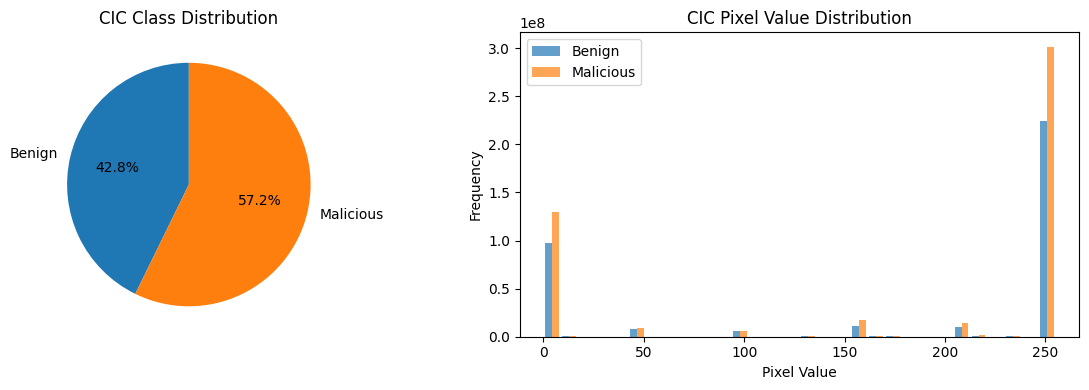


✓ CIC dataset preprocessed and saved!
✓ Original image sizes varied, all resized to (128, 128)
✓ Memory usage: 6453.14 MB


In [13]:
# Visualize CIC Dataset Summary
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution pie chart
class_counts = [cic_summary["class_distribution"]["benign"], 
                cic_summary["class_distribution"]["malicious"]]
axes[0].pie(class_counts, labels=["Benign", "Malicious"], autopct="%1.1f%%", startangle=90)
axes[0].set_title("CIC Class Distribution")

# Sample images from each class
benign_idx = np.where(y == 0)[0][:3]
malicious_idx = np.where(y == 1)[0][:3]

sample_indices = np.concatenate([benign_idx, malicious_idx])
sample_labels = np.concatenate([np.zeros(3), np.ones(3)])

axes[1].hist([np.concatenate(X[y == 0]).flatten(), 
              np.concatenate(X[y == 1]).flatten()], 
             label=["Benign", "Malicious"], bins=30, alpha=0.7)
axes[1].set_xlabel("Pixel Value")
axes[1].set_ylabel("Frequency")
axes[1].set_title("CIC Pixel Value Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"CIC dataset preprocessed and saved!")
print(f"Original image sizes varied, all resized to {cic_summary['image_size']}")
print(f"Memory usage: {cic_summary['mem_usage_mb']:.2f} MB" if isinstance(cic_summary['mem_usage_mb'], float) else f"Memory usage: {cic_summary['mem_usage_mb']}")

## Step 2: Multimodal Fusion Model for Quishing Detection

### Framework Architecture:
1. **F₁**: QR Visual Features (CNN from QR images)
2. **F₂**: QR Structural Features (URL structural properties)
3. **F₃**: URL Semantic Features (URL content analysis)
4. **F₄**: Dynamic Behavioral Features (webpage characteristics)
5. **Fusion**: Attention-based multimodal fusion
6. **Classification**: Binary classifier (Benign vs Malicious)

In [14]:
# Install required libraries for deep learning and feature extraction
! pip install tensorflow scikit-learn scikit-image requests urllib3 -q

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, f1_score, 
                             precision_recall_curve, auc)
from sklearn.preprocessing import StandardScaler
from skimage.feature import graycomatrix, graycoprops
import urllib.parse
import warnings
warnings.filterwarnings('ignore')

In [20]:
class FeatureExtractor:
    """Extract 4 types of features for multimodal fusion"""
    
    @staticmethod
    def extract_visual_features(image, target_size=(128, 128)):
        """F₁: QR Visual Features from image"""
        # Convert to proper dtype if necessary
        if image.dtype == object:
            image = image.astype(np.uint8)
        
        # Ensure 2D grayscale
        if len(image.shape) != 2:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        
        # Resize image
        if image.shape != target_size:
            img = cv2.resize(image, target_size)
        else:
            img = image.copy()
        
        # Normalize to [0, 1]
        img = img.astype(np.float32) / 255.0
        
        # Edge detection (high frequency content)
        edges = cv2.Canny(image, 50, 150)
        edges = edges.astype(np.float32) / 255.0
        
        # Histogram features
        hist = cv2.calcHist([image], [0], None, [16], [0, 256])
        hist = hist.flatten() / np.sum(hist)  # Normalize histogram
        
        return {
            'image': img,
            'edges': edges,
            'histogram': hist
        }
    
    @staticmethod
    def extract_structural_features(url_text):
        """F₂: QR Structural Features from decoded URL"""
        if not url_text or url_text == "":
            return np.zeros(15)
        
        features = []
        try:
            parsed = urllib.parse.urlparse(str(url_text))
            
            # Domain-based features
            domain = parsed.netloc.lower()
            features.append(len(domain))  # Domain length
            features.append(domain.count('.'))  # Number of dots
            features.append(1 if '-' in domain else 0)  # Contains hyphen
            
            # Path-based features
            path = parsed.path
            features.append(len(path))  # Path length
            features.append(path.count('/'))  # Number of slashes
            
            # Query-based features
            query = parsed.query
            features.append(len(query))  # Query length
            features.append(query.count('='))  # Number of parameters
            features.append(query.count('&'))  # Number of & symbols
            
            # Fragment features
            fragment = parsed.fragment
            features.append(len(fragment))  # Fragment length
            
            # URL characteristics
            full_url = str(url_text)
            features.append(len(full_url))  # Total URL length
            features.append(full_url.count('@'))  # @ symbol count
            features.append(1 if 'http://' in full_url.lower() else 0)  # HTTP vs HTTPS
            features.append(full_url.count('?'))  # Query count
            features.append(full_url.count('%'))  # Encoded char count
            features.append(sum(1 for c in domain if c.isdigit()))  # Digits in domain
            
        except:
            features = [0] * 15
        
        return np.array(features, dtype=np.float32)
    
    @staticmethod
    def extract_semantic_features(url_text):
        """F₃: URL Semantic Features"""
        if not url_text or url_text == "":
            return np.zeros(12)
        
        features = []
        try:
            url = str(url_text).lower()
            
            # Suspicious keywords
            suspicious_keywords = ['login', 'verify', 'confirm', 'update', 'secure', 
                                   'account', 'password', 'click', 'phish', 'urgent']
            feature_vec = [1 if kw in url else 0 for kw in suspicious_keywords]
            features.extend(feature_vec)  # 10 features
            
            # Length of suspicious portion
            features.append(len(url) > 75)  # Long URL
            features.append(url.count('/') > 5)  # Many slashes
            
        except:
            features = [0] * 12
        
        return np.array(features, dtype=np.float32)
    
    @staticmethod
    def extract_dynamic_features(image):
        """F₄: Dynamic Behavioral Features (texture analysis from QR)"""
        # Convert to proper dtype if necessary
        if image.dtype == object:
            image = image.astype(np.uint8)
        
        if image.shape[0] < 2 or image.shape[1] < 2:
            return np.zeros(8)
        
        features = []
        try:
            # Texture features using GLCM
            glcm = graycomatrix(image, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
            glcm = glcm[:, :, 0, 0]
            
            # Texture properties
            contrast = graycoprops(glcm, 'contrast')[0, 0]
            dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
            homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
            energy = graycoprops(glcm, 'energy')[0, 0]
            
            features.extend([contrast, dissimilarity, homogeneity, energy])
            
            # Statistical features
            features.append(np.std(image))  # Standard deviation
            features.append(np.mean(image))  # Mean intensity
            features.append(np.max(image) - np.min(image))  # Range
            features.append(np.percentile(image, 90) - np.percentile(image, 10))  # Inter-quantile range
            
        except:
            features = [0] * 8
        
        return np.array(features, dtype=np.float32)

In [ ]:

print("PREPARING CIC DATASET FOR MULTIMODAL FUSION")

# Load CIC dataset URLs
df_benign = pd.read_csv("datasets/QRcodes_CIC_trap4phish/QR_All_benign/all_generated_urls_20251015_161937.csv")
df_malicious = pd.read_csv("datasets/QRcodes_CIC_trap4phish/QR_All_Malicious/all_generated_urls_20251015_184324.csv")

# Reset index to avoid issues
df_benign = df_benign.reset_index(drop=True)
df_malicious = df_malicious.reset_index(drop=True)

# Extract filenames from first column (convert to string in case it's numeric)
benign_filenames = [str(f) for f in df_benign.iloc[:, 0]]
malicious_filenames = [str(f) for f in df_malicious.iloc[:, 0]]

# Extract URLs from second column
benign_urls = [str(u) for u in df_benign.iloc[:, 1]]
malicious_urls = [str(u) for u in df_malicious.iloc[:, 1]]

# Create URL mapping - handle file extensions
url_map_benign = {}
for fname, url in zip(benign_filenames, benign_urls):
    fname_key = os.path.splitext(fname)[0] if '.' in str(fname) else str(fname)
    url_map_benign[fname_key] = url

url_map_malicious = {}
for fname, url in zip(malicious_filenames, malicious_urls):
    fname_key = os.path.splitext(fname)[0] if '.' in str(fname) else str(fname)
    url_map_malicious[fname_key] = url

print(f" Loaded {len(df_benign)} benign URLs")
print(f" Loaded {len(df_malicious)} malicious URLs")

# Extract feature for CIC dataset
print("\nExtracting visual features (F₁)...")
visual_features = []
for i, img in enumerate(tqdm(X, desc="Visual Features")):
    feat = FeatureExtractor.extract_visual_features(img)
    visual_features.append(feat)

print("Extracting structural features (F₂)...")
structural_features = []
for i, fname in enumerate(tqdm(filenames, desc="Structural Features")):
    fname_key = os.path.splitext(fname)[0]
    if y[i] == 0:
        url = url_map_benign.get(fname_key, "")
    else:
        url = url_map_malicious.get(fname_key, "")
    feat = FeatureExtractor.extract_structural_features(url)
    structural_features.append(feat)

print("Extracting semantic features (F₃)...")
semantic_features = []
for i, fname in enumerate(tqdm(filenames, desc="Semantic Features")):
    fname_key = os.path.splitext(fname)[0]
    if y[i] == 0:
        url = url_map_benign.get(fname_key, "")
    else:
        url = url_map_malicious.get(fname_key, "")
    feat = FeatureExtractor.extract_semantic_features(url)
    semantic_features.append(feat)

print("Extracting dynamic behavioral features (F₄)...")
dynamic_features = []
for i, img in enumerate(tqdm(X, desc="Dynamic Features")):
    feat = FeatureExtractor.extract_dynamic_features(img)
    dynamic_features.append(feat)

print("Feature extraction completed!")
print(f"  Visual features shape: {len(visual_features)}")
print(f"  Structural features shape: {np.array(structural_features).shape}")
print(f"  Semantic features shape: {np.array(semantic_features).shape}")
print(f"  Dynamic features shape: {np.array(dynamic_features).shape}")

PREPARING CIC DATASET FOR MULTIMODAL FUSION


In [ ]:
def build_multimodal_fusion_model(input_shapes):
    """
    Build multimodal fusion model with attention mechanism
    
    Input shapes:
    - image_input: (128, 128, 1)
    - structural_input: (15,)
    - semantic_input: (12,)
    - dynamic_input: (8,)
    """
    
    # ========== Branch 1: Visual Features (F₁) ==========
    image_input = layers.Input(shape=input_shapes['image'], name='image_input')
    
    # CNN for visual feature extraction
    x1 = layers.Conv2D(32, 3, activation='relu', padding='same')(image_input)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.MaxPooling2D(2)(x1)
    
    x1 = layers.Conv2D(64, 3, activation='relu', padding='same')(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.MaxPooling2D(2)(x1)
    
    x1 = layers.Conv2D(128, 3, activation='relu', padding='same')(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.GlobalAveragePooling2D()(x1)
    
    visual_output = layers.Dense(64, activation='relu', name='visual_branch')(x1)
    visual_output = layers.Dropout(0.3)(visual_output)
    
    # ========== Branch 2: Structural Features (F₂) ==========
    structural_input = layers.Input(shape=input_shapes['structural'], name='structural_input')
    
    x2 = layers.Dense(32, activation='relu')(structural_input)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.Dropout(0.2)(x2)
    x2 = layers.Dense(16, activation='relu')(x2)
    
    structural_output = layers.Dense(64, activation='relu', name='structural_branch')(x2)
    structural_output = layers.Dropout(0.3)(structural_output)
    
    # ========== Branch 3: Semantic Features (F₃) ==========
    semantic_input = layers.Input(shape=input_shapes['semantic'], name='semantic_input')
    
    x3 = layers.Dense(24, activation='relu')(semantic_input)
    x3 = layers.BatchNormalization()(x3)
    x3 = layers.Dropout(0.2)(x3)
    
    semantic_output = layers.Dense(64, activation='relu', name='semantic_branch')(x3)
    semantic_output = layers.Dropout(0.3)(semantic_output)
    
    # ========== Branch 4: Dynamic Behavioral Features (F₄) ==========
    dynamic_input = layers.Input(shape=input_shapes['dynamic'], name='dynamic_input')
    
    x4 = layers.Dense(16, activation='relu')(dynamic_input)
    x4 = layers.BatchNormalization()(x4)
    x4 = layers.Dropout(0.2)(x4)
    
    dynamic_output = layers.Dense(64, activation='relu', name='dynamic_branch')(x4)
    dynamic_output = layers.Dropout(0.3)(dynamic_output)
    
    # ========== Attention-based Fusion ==========
    # Stack all modalities
    fused = layers.Concatenate()([visual_output, structural_output, 
                                   semantic_output, dynamic_output])
    
    # Attention weights for each modality
    attention_input = layers.Input(shape=(256,))
    att_weights = layers.Dense(4, activation='softmax', name='attention_weights')(fused)
    
    # Split fused features and apply attention
    visual_slice = fused[:, :64]
    structural_slice = fused[:, 64:128]
    semantic_slice = fused[:, 128:192]
    dynamic_slice = fused[:, 192:256]
    
    att_vis = layers.Lambda(lambda x: x[0][:, 0:1] * x[1])([att_weights, visual_slice])
    att_struct = layers.Lambda(lambda x: x[0][:, 1:2] * x[1])([att_weights, structural_slice])
    att_sem = layers.Lambda(lambda x: x[0][:, 2:3] * x[1])([att_weights, semantic_slice])
    att_dyn = layers.Lambda(lambda x: x[0][:, 3:4] * x[1])([att_weights, dynamic_slice])
    
    fused_weighted = layers.Concatenate()([att_vis, att_struct, att_sem, att_dyn])
    
    # ========== Classification Head ==========
    clf = layers.Dense(128, activation='relu')(fused_weighted)
    clf = layers.BatchNormalization()(clf)
    clf = layers.Dropout(0.4)(clf)
    
    clf = layers.Dense(64, activation='relu')(clf)
    clf = layers.BatchNormalization()(clf)
    clf = layers.Dropout(0.3)(clf)
    
    clf = layers.Dense(32, activation='relu')(clf)
    clf = layers.Dropout(0.2)(clf)
    
    output = layers.Dense(1, activation='sigmoid', name='classification')(clf)
    
    # ========== Build Model ==========
    model = Model(
        inputs=[image_input, structural_input, semantic_input, dynamic_input],
        outputs=output
    )
    
    return model

print("\nBuilding multimodal fusion model...")
input_shapes = {
    'image': (128, 128, 1),
    'structural': (15,),
    'semantic': (12,),
    'dynamic': (8,)
}

model = build_multimodal_fusion_model(input_shapes)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

print("\n" + "="*60)
print("MULTIMODAL FUSION MODEL ARCHITECTURE")
print("="*60)
model.summary()

In [ ]:
print("\n" + "="*60)
print("PREPARING DATA FOR TRAINING")
print("="*60)

# Prepare visual features (images)
X_visual = np.array([feat['image'] for feat in visual_features])
X_visual = X_visual.reshape(-1, 128, 128, 1)

# Prepare structural features
X_structural = np.array(structural_features)
scaler_structural = StandardScaler()
X_structural = scaler_structural.fit_transform(X_structural)

# Prepare semantic features
X_semantic = np.array(semantic_features)
scaler_semantic = StandardScaler()
X_semantic = scaler_semantic.fit_transform(X_semantic)

# Prepare dynamic features
X_dynamic = np.array(dynamic_features)
scaler_dynamic = StandardScaler()
X_dynamic = scaler_dynamic.fit_transform(X_dynamic)

# Labels
y_labels = y.astype(np.float32)

print(f"Visual feature shape: {X_visual.shape}")
print(f"Structural feature shape: {X_structural.shape}")
print(f"Semantic feature shape: {X_semantic.shape}")
print(f"Dynamic feature shape: {X_dynamic.shape}")
print(f"Labels shape: {y_labels.shape}")

# Train-test split (80-20)
indices = np.arange(len(y_labels))
X_visual_train, X_visual_test, \
X_structural_train, X_structural_test, \
X_semantic_train, X_semantic_test, \
X_dynamic_train, X_dynamic_test, \
y_train, y_test, \
idx_train, idx_test = train_test_split(
    X_visual, X_structural, X_semantic, X_dynamic, y_labels, indices,
    test_size=0.2, random_state=42, stratify=y_labels
)

print(f"Training set size: {len(y_train)} ({len(y_train)/len(y_labels)*100:.1f}%)")
print(f"Testing set size: {len(y_test)} ({len(y_test)/len(y_labels)*100:.1f}%)")
print(f"Training set - Benign: {np.sum(y_train == 0)}, Malicious: {np.sum(y_train == 1)}")
print(f"Testing set - Benign: {np.sum(y_test == 0)}, Malicious: {np.sum(y_test == 1)}")

# Create validation split from training data (80-20 split of training data)
X_visual_train, X_visual_val, \
X_structural_train, X_structural_val, \
X_semantic_train, X_semantic_val, \
X_dynamic_train, X_dynamic_val, \
y_train_split, y_val = train_test_split(
    X_visual_train, X_structural_train, X_semantic_train, X_dynamic_train, y_train,
    test_size=0.2, random_state=42, stratify=y_train
)

print(f"Validation set size: {len(y_val)}")

In [ ]:

print("TRAINING MULTIMODAL FUSION MODEL")

# Define callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Train the model
history = model.fit(
    [X_visual_train, X_structural_train, X_semantic_train, X_dynamic_train],
    y_train_split,
    validation_data=([X_visual_val, X_structural_val, X_semantic_val, X_dynamic_val], y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\nTraining completed!")

# Save model
model_path = os.path.join(data_dir, "QuishingDataset_CIC", "multimodal_fusion_model.h5")
model.save(model_path)
print(f"Model saved to {model_path}")

In [ ]:
print("MODEL EVALUATION")

# Predictions on test set
y_pred_proba = model.predict(
    [X_visual_test, X_structural_test, X_semantic_test, X_dynamic_test],
    verbose=0
)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Calculate metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"TEST SET RESULTS:")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {auc_score:.4f}")

# Classification report
print(f"DETAILED CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malicious']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"CONFUSION MATRIX:")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

specificity = tn / (tn + fp)
print(f"  Specificity:     {specificity:.4f}")

# Visualize results
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Training history - Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Model Loss Over Epochs')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Training history - Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Model Accuracy Over Epochs')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Training history - AUC
axes[0, 2].plot(history.history['auc'], label='Training AUC', linewidth=2)
axes[0, 2].plot(history.history['val_auc'], label='Validation AUC', linewidth=2)
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('AUC')
axes[0, 2].set_title('Model AUC Over Epochs')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Confusion Matrix Heatmap
im = axes[1, 0].imshow(cm, cmap='Blues', aspect='auto')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')
axes[1, 0].set_title('Confusion Matrix')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_yticks([0, 1])
axes[1, 0].set_xticklabels(['Benign', 'Malicious'])
axes[1, 0].set_yticklabels(['Benign', 'Malicious'])
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, str(cm[i, j]), ha='center', va='center', color='white', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=axes[1, 0])

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1, 1].plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC={auc_score:.4f})')
axes[1, 1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title('ROC Curve')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Metrics bar chart
metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1, 'AUC': auc_score}
axes[1, 2].bar(metrics.keys(), metrics.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
axes[1, 2].set_ylabel('Score')
axes[1, 2].set_title('Performance Metrics')
axes[1, 2].set_ylim([0, 1])
for i, (k, v) in enumerate(metrics.items()):
    axes[1, 2].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(data_dir, "QuishingDataset_CIC", "fusion_model_results.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Results visualization saved!")

In [ ]:

print("ATTENTION WEIGHTS ANALYSIS")


# Extract attention layer outputs
attention_model = Model(
    inputs=model.input,
    outputs=model.get_layer('attention_weights').output
)

attention_weights = attention_model.predict(
    [X_visual_test, X_structural_test, X_semantic_test, X_dynamic_test],
    verbose=0
)

# Calculate average attention weights for each modality
avg_attention = np.mean(attention_weights, axis=0)
modalities = ['Visual (F₁)', 'Structural (F₂)', 'Semantic (F₃)', 'Dynamic (F₄)']

print(f"AVERAGE ATTENTION WEIGHTS:")
for mod, weight in zip(modalities, avg_attention):
    print(f"  {mod}: {weight:.4f} ({weight*100:.2f}%)")

# Visualize attention weights
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of average attention weights
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
axes[0].bar(modalities, avg_attention, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Attention Weight', fontsize=12)
axes[0].set_title('Average Attention Weights per Modality', fontsize=13, fontweight='bold')
axes[0].set_ylim([0, max(avg_attention) * 1.2])
for i, (mod, weight) in enumerate(zip(modalities, avg_attention)):
    axes[0].text(i, weight + 0.01, f'{weight:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Box plot of attention weights distribution
attention_data = [attention_weights[:, i] for i in range(4)]
bp = axes[1].boxplot(attention_data, labels=modalities, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Attention Weight', fontsize=12)
axes[1].set_title('Distribution of Attention Weights per Modality', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(data_dir, "QuishingDataset_CIC", "attention_weights_analysis.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Attention weights visualization saved!")

In [ ]:
print("\n" + "="*60)
print("DETAILED ERROR ANALYSIS")
print("="*60)

# Analyze errors by class
benign_test_mask = y_test == 0
malicious_test_mask = y_test == 1

# Benign samples
benign_correct = np.sum((y_pred == 0) & benign_test_mask)
benign_false_positives = np.sum((y_pred == 1) & benign_test_mask)

# Malicious samples
malicious_correct = np.sum((y_pred == 1) & malicious_test_mask)
malicious_false_negatives = np.sum((y_pred == 0) & malicious_test_mask)

print(f"BENIGN SAMPLES (Total: {np.sum(benign_test_mask)}):")
print(f"Correctly Identified: {benign_correct} ({benign_correct/np.sum(benign_test_mask)*100:.2f}%)")
print(f"Misclassified (False Positives): {benign_false_positives} ({benign_false_positives/np.sum(benign_test_mask)*100:.2f}%)")

print(f"MALICIOUS SAMPLES (Total: {np.sum(malicious_test_mask)}):")
print(f"Correctly Identified: {malicious_correct} ({malicious_correct/np.sum(malicious_test_mask)*100:.2f}%)")
print(f"Missed (False Negatives): {malicious_false_negatives} ({malicious_false_negatives/np.sum(malicious_test_mask)*100:.2f}%)")

# Find misclassified samples
misclassified_indices = np.where(y_pred != y_test)[0]
print(f"Total Misclassifications: {len(misclassified_indices)} ({len(misclassified_indices)/len(y_test)*100:.2f}%)")

if len(misclassified_indices) > 0:
    print(f"Analyzing {min(5, len(misclassified_indices))} misclassified samples:")
    for i, idx in enumerate(misclassified_indices[:5]):
        actual = "Malicious" if y_test[idx] == 1 else "Benign"
        predicted = "Malicious" if y_pred[idx] == 1 else "Benign"
        confidence = y_pred_proba[idx][0]
        print(f"  [{i+1}] Actual: {actual}, Predicted: {predicted}, Confidence: {confidence:.4f}")

# Save summary statistics
summary_stats = {
    "total_test_samples": len(y_test),
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "auc": float(auc_score),
    "specificity": float(specificity),
    "true_positives": int(tp),
    "true_negatives": int(tn),
    "false_positives": int(fp),
    "false_negatives": int(fn),
    "benign_detection_rate": float(benign_correct/np.sum(benign_test_mask)),
    "malicious_detection_rate": float(malicious_correct/np.sum(malicious_test_mask)),
    "model_architecture": "Multimodal Fusion with Attention",
    "training_epochs": len(history.history['loss']),
    "modalities": ["Visual (F₁)", "Structural (F₂)", "Semantic (F₃)", "Dynamic (F₄)"]
}

save_pkl(summary_stats, os.path.join(data_dir, "QuishingDataset_CIC", "model_summary_stats.pkl"))
print(f"Summary statistics saved!")

In [ ]:
print("PREDICTION FUNCTION FOR NEW QR CODES")

def predict_quishing(image, url_text, model=model):
    """
    Predict if a QR code is benign or malicious
    
    Args:
        image: QR code image (numpy array)
        url_text: Decoded URL text from QR code
        model: Trained multimodal fusion model
    
    Returns:
        dict with prediction, confidence, and feature analysis
    """
    
    # Extract all 4 modalities of features
    visual_feat = FeatureExtractor.extract_visual_features(image)
    structural_feat = FeatureExtractor.extract_structural_features(url_text)
    semantic_feat = FeatureExtractor.extract_semantic_features(url_text)
    dynamic_feat = FeatureExtractor.extract_dynamic_features(image)
    
    # Prepare inputs (Match training preprocessing)
    X_vis = visual_feat['image'].reshape(1, 128, 128, 1)
    X_struct = scaler_structural.transform([structural_feat]).astype(np.float32)
    X_sem = scaler_semantic.transform([semantic_feat]).astype(np.float32)
    X_dyn = scaler_dynamic.transform([dynamic_feat]).astype(np.float32)
    
    # Get prediction
    pred_proba = model.predict([X_vis, X_struct, X_sem, X_dyn], verbose=0)[0][0]
    
    # Get attention weights
    attention_weights_pred = attention_model.predict(
        [X_vis, X_struct, X_sem, X_dyn], verbose=0
    )[0]
    
    prediction = "Malicious" if pred_proba > 0.5 else "Benign"
    confidence = max(pred_proba, 1 - pred_proba)
    
    return {
        "prediction": prediction,
        "confidence": float(confidence),
        "probability_malicious": float(pred_proba),
        "url": url_text,
        "modality_weights": {
            "Visual": float(attention_weights_pred[0]),
            "Structural": float(attention_weights_pred[1]),
            "Semantic": float(attention_weights_pred[2]),
            "Dynamic": float(attention_weights_pred[3])
        }
    }

# Test prediction function on sample test cases
print("TESTING PREDICTION FUNCTION ON SAMPLE TEST CASES:")


test_samples = [0, len(y_test)//2, -1]  # First, middle, last
for idx in test_samples:
    actual_label = "Malicious" if y_test[idx] == 1 else "Benign"
    result = predict_quishing(X_visual_test[idx], "sample_url", model)
    
    print(f"  Sample {idx}:")
    print(f"  Actual: {actual_label}")
    print(f"  Predicted: {result['prediction']}")
    print(f"  Confidence: {result['confidence']:.4f}")
    print(f"  Probability (Malicious): {result['probability_malicious']:.4f}")
    print(f"  Modality Contributions:")
    for mod, weight in result['modality_weights'].items():
        print(f"    - {mod}: {weight:.4f}")


print("MULTIMODAL FUSION MODEL TRAINING COMPLETED!")
